# Covariance and Correlation

::: {#def-covariance}
## Covariance

The covariance between two variables $x$ and $y$ with $n$ values is defined as

$$
S_{xy} = \frac{1}{n - 1} \sum_{i=1}^n (x_i - \overline{x})(y_i - \overline{y})
$$
:::

::: {#def-variance-decomposition}
## Variance decomposition

We have already defined the variance of a variable $x$ as

$$
S_x^2 = \frac{1}{n - 1} \sum_{i=1}^n (x_i - \overline{x})^2
$$

It can be shown that the variance of $x$ can be decomposed into the sum of the squared mean and the variance of the deviations from the mean.

$$
S_x^2 = \frac{n}{n  - 1}(\overline{x_i^2} - \overline{x}^2)
$$
:::

::: {.callout-note .proof collapse="true"}
For the proof we just write out the square in the sum and rearrange the terms.

$$
\begin{align*}
(n - 1) S_x^2 & =  \sum_{i=1}^n (x_i - \overline{x})^2 \\
& =  \sum_{i=1}^n (x_i^2 - 2x_i \overline{x} + \overline{x}^2) \\
& =  \sum_{i=1}^n x_i^2 - 2\overline{x} \sum_{i=1}^n x_i + \overline{x}^2 \sum_{i=1}^n 1 \\
& =  \sum_{i=1}^n x_i^2 - 2\overline{x} \sum_{i=1}^n x_i + \overline{x}^2 n \\
& =  \sum_{i=1}^n x_i^2 - 2\overline{x}^2 n + \overline{x}^2 n \\
& =  \sum_{i=1}^n x_i^2 - n \overline{x}^2 \\
& = n (\overline{x_i^2} - \overline{x}^2)
\end{align*}
$$
:::

<div>

## Covariance

The covariance between two variables $x$ and $y$ with $n$ values is defined as

$$
S_{xy} = \frac{1}{n - 1} \sum_{i=1}^n (x_i - \overline{x})(y_i - \overline{y})
$$

Much in the same way as the variance, the covariance can be decomposed into the sum of the squared mean and the variance of the deviations from the mean.

$$
S_{xy} = \frac{n}{(n - 1)}(\overline{x y} - \overline{x} \overline{y})
$$

The proof is similar to the proof for the variance decomposition.

</div>

::: {.callout-note .proof collapse="true"}
For the proof we just write out the product in the sum and rearrange the terms.

$$
\begin{align*}
(n - 1) S_{xy} & = \sum_{i=1}^n (x_i - \overline{x})(y_i - \overline{y}) \\
& = \sum_{i=1}^n x_i y_i - \overline{x} \sum_{i=1}^n y_i - \overline{y} \sum_{i=1}^n x_i + n \overline{x} \overline{y} \\
& = n(\overline{x y} - \overline{x} \overline{y})
\end{align*}
$$
:::

To understand what the covariance measures, consider the following scatterplot:



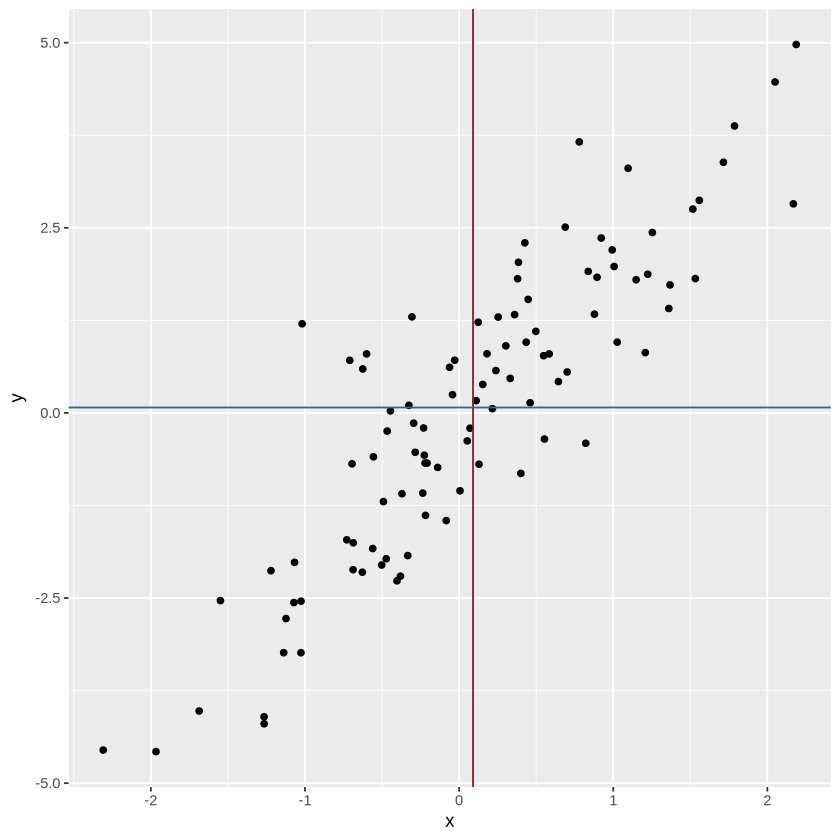

In [ ]:
#| label: fig-covariance-positive
#| fig-cap: "Scatterplot of two variables with a positive linear assocition"

set.seed(123)
dt_pos_cov <- tibble(
    x = rnorm(100),
    y = 2 * x + rnorm(100)
)

dt_pos_cov |>
    ggplot(aes(x = x, y = y)) +
    geom_point() +
    geom_vline(xintercept = mean(dt_pos_cov$x), colour = "firebrick4") +
    geom_hline(yintercept = mean(dt_pos_cov$y), colour = "steelblue4")



The reddish line is drawn at the average of the $x$ values and the bluish line is drawn at the average of the $y$ values. The covariance measures the average product of the deviations of the $x$ and $y$ values from their respective means. If the product is positive, it means that when $x$ is above its average, $y$ is also above its average. If the product is negative, it means that when $x$ is above its average, $y$ is below its average.

You can compute the empirical covariance between two variables using the `cov` function in R.



In [ ]:
cov(dt_pos_cov$x, dt_pos_cov$y)

[1] 1.622745



Only the *sign* of the covariance is important. The magnitude of the covariance depends on the units of the variables. To make the covariance unit-free, we can divide it by the product of the standard deviations of the two variables. This gives us the correlation coefficient.



In [ ]:
cov(dt_pos_cov$x * 1000, dt_pos_cov$y)
cov(dt_pos_cov$x , dt_pos_cov$y * 50)

[1] 1622.745

[1] 81.13723

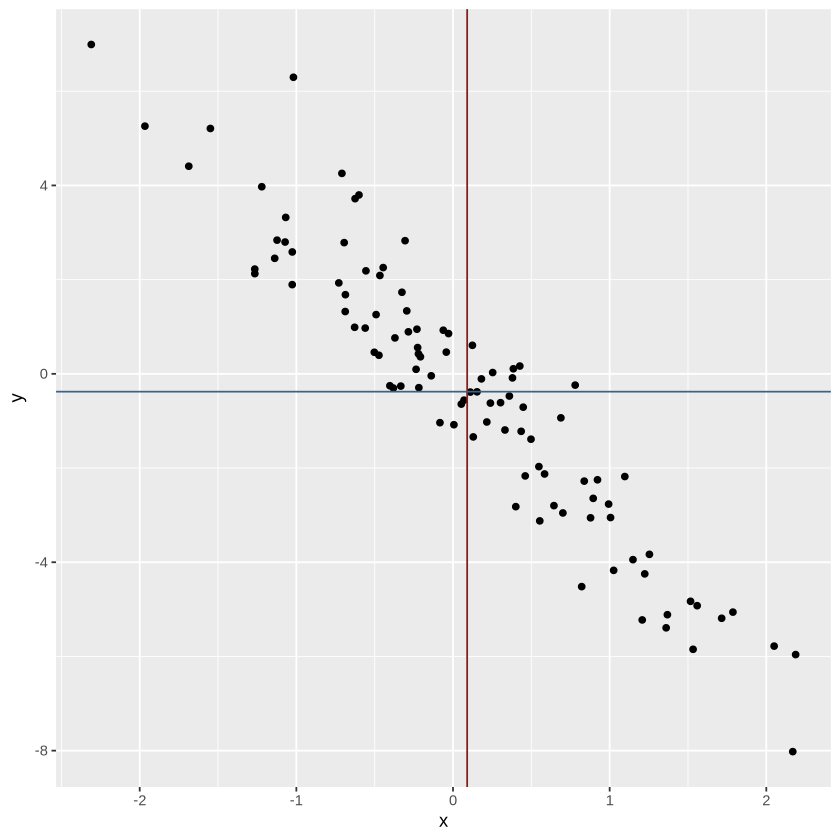

In [ ]:
#| label: fig-covariance-negative
#| fig-cap: "Scatterplot of two variables with a positive linear assocition"

set.seed(123)
dt_neg_cov <- tibble(
    x = rnorm(100),
    y = -3 * x + rnorm(100)
)

dt_neg_cov |>
    ggplot(aes(x = x, y = y)) +
    geom_point() +
    geom_vline(xintercept = mean(dt_neg_cov$x), colour = "firebrick4") +
    geom_hline(yintercept = mean(dt_neg_cov$y), colour = "steelblue4")

In [ ]:
cov(dt_neg_cov$x, dt_neg_cov$y)

[1] -2.54342



::: {#def-correlation}
## Correlation

The correlation between two variables $x$ and $y$ with $n$ values is defined as

$$
r_{xy} = \frac{S_{xy}}{S_x S_y}
$$

where $S_{xy}$ is the covariance between $x$ and $y$, and $S_x$ and $S_y$ are the standard deviations of $x$ and $y$ respectively.
:::

Because the covariance is divided by the product of the standard deviations, the correlation is unit-free. Furthermore, the correlation is always between -1 and 1. A correlation of 1 means that the two variables lie on a straight line with a positive slope. A correlation of -1 means that the two variables lie on a straight line with a negative slope. A correlation of 0 means that there is no *linear* association between the two variables.



In [ ]:
cor(dt_pos_cov$x, dt_pos_cov$y)
cor(dt_neg_cov$x, dt_neg_cov$y)

[1] 0.8786993

[1] -0.9448502



## Exercise

Write a function that takes two vectors `x` and `y` as arguments and returns the OLS coefficients $\hat{\beta}_0$ and $\hat{\beta}_1$ using the formulas above.



In [ ]:
ols_two_variables <- function(x, y){
    # Compute the coefficients
    beta_1_hat <- (mean(x * y) - mean(x) * mean(y)) / (mean(x^2) - mean(x)^2)
    beta_0_hat <- mean(y) - beta_1_hat * mean(x)

    c(beta_0_hat = beta_0_hat, beta_1_hat = beta_1_hat)
}



Test your function using the following data set.



In [ ]:
set.seed(123)

x_test <- rnorm(100)
y_test <- 1 + 2 * x_test + rnorm(100)

print(ols_two_variables(x_test, y_test))
print(lm(y_test ~ x_test))

beta_0_hat beta_1_hat 
 0.8971969  1.9475284 

Call:
lm(formula = y_test ~ x_test)

Coefficients:
(Intercept)       x_test  
     0.8972       1.9475  





Compare your results with the `lm` function in R.



In [ ]:
# Uncomment the following line to compare your results with the lm function

# ols_two_variables(x, y)
lm(y_test ~ x_test)


Call:
lm(formula = y_test ~ x_test)

Coefficients:
(Intercept)       x_test  
     0.8972       1.9475  
